In [3]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

C:\Users\manoj\PycharmProjects\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()

True

In [5]:
model = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

In [6]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [8]:
graph = builder.compile()

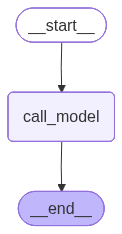

In [9]:
graph

In [10]:
res = graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Manoj."}]})

In [11]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='eba791ae-8897-465b-bb78-a5d7a1d01db2'),
  AIMessage(content=[{'type': 'text', 'text': "I don’t know your name because I don’t have access to your personal information or your physical identity. \n\nIf you've told me your name earlier in this conversation, I might be able to remember it, but otherwise, you are anonymous to me! What would you like me to call you?", 'extras': {'signature': 'ErIDCq8DAQw51sfhAi560Aw76lsJI2ivHW1pAVkGJnWa03fVeMp7GvWjF7T0nHdvZ1ouMFVZj9QANbKNSDDCnMydBvknMVIid9vy2DXJL4zbuu1JnEjMuaPkjbauNmvltKUi5H0xC52aAmdLfpY8h2RpUzw4xx0pK2QVmtMH0W9LF/oZP4e15/RlfCSZWf9FUDOo1Ixlx/i4XLMMjtj4MO3Nu7VZszn2ogsDoS7fTI+ufgiexQlw+EUT3d++1ufcdDhwIeYcdUEZGCyGQgd91Eblh4Vd66sl2mbFkBVKpv4NVCe4SToERLpTRBUvrNdRTxi9PsXhyfFjmf7qLf+LTCXJHRUx6popKxtvKsSzL0uiZh9LXTEPE/r8MJPzzV0kDBgtW8xMeX2L0d0n1fm8XgOnjM6++9pBDllL1RB7hqY9nJdMQGfl/0UYDrMLbjgCdqAsiAkkAumePwgBe0UA7BuSVuWtgc/5Ogb6QQKR6dZrkxfwlNNJH0A2LB

In [12]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [13]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [14]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [15]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}
input = {"messages": [{"role": "user", "content": "Hi! My name is Manoj."}]}

In [16]:
graph.invoke(input=input, config=config)

{'messages': [HumanMessage(content='Hi! My name is Manoj.', additional_kwargs={}, response_metadata={}, id='c199647e-fb63-4fcd-bac3-15a56f666e08'),
  AIMessage(content=[{'type': 'text', 'text': "Hello, Manoj! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'EqkCCqYCAQw51sdfq69SGq+JhtNv0mxqUe8t45z8og3YFrd0Elb9l5hUxB80TqpDOSygZuVcSu6WXlsi5nMCc/RBQ9fMXyH9gk5OPqdxtoYLyFTHNCv9mt4U4niboryo1gbFXO6pbZY5OU6XRyntW5mq+vCDp6qXlGAgjl0ezKy5gA4BKGTfuonqAmJSB1AXn8uqdNRbrtOHK7zg0rYDD5tVEFNINiiOKCdFnnHogW/t8tsZjcVN8oboWENOK7WX6XP3+fXsIyscxTMd9gcI1mfRLkjg7rdLPAGV8JjN3vrSo7Td39CBp6I6lfFs7hyAkHSSDd3Ey67yrVjI3PvSaDd3uhdKlDQp7xpapHOP0rCyEH7SG7bO4TC+5X8vZj/4oY36VyzqHDmqmEUW'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d9a8f-c3f5-7340-81a1-9d7cdc6119d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 81,

In [27]:
input2 = {"messages": [{"role": "user", "content": "Hi! What is the capital of India"}]}
graph.invoke(input=input2, config=config2)

{'messages': [HumanMessage(content='Hi! What is  my name?', additional_kwargs={}, response_metadata={}, id='77060bdd-ecd4-4aa8-aad5-cbef4fbd7e6b'),
  AIMessage(content=[{'type': 'text', 'text': 'I don’t know your name yet! As an AI, I don’t have access to your personal information unless you share it with me.\n\nWhat would you like me to call you?', 'extras': {'signature': 'Eo0JCooJAQw51sdRaLwH4qwX07s9VjELANdQs9OCYHescq/eS2+8PEzpo6uPD3Z07YD2kxNW/r+EsMIQ9tJGm1DvT+5crDVb+Hb48R5fiTV4meM2DMqlXPBhpg0iFRZjKDSB3ZmBLU4norBPnoXdoPif08eYrGlyhp7GkAML9W3LCk2ZCOZ/ZIdmk8Ok4C5SF32lRg65Z4Uc6DgH4OKZ0M2edywXesuURY8cXs3gWrKZfT9guh2eEudfKlXuPGrbbHHdTSgfQ7qhmzvwCk6Gqvps7oHTP/YXwcAtShAoREVBQB4G7Itygfep4Lb3m1bTRoUCFIdBRAem72LIqJI9iDjL2X6EulsYHY2UUtw2rgSsX7Xe8Vcw7NKZP9pGKIhDD1Q3AWqdgDyTL3CX6uMwweZHCuo1Li45oizJBQAKDgYpGZ2jG9WrvldrExUbxX+upCfUszD12yHw7iR8qY6U8cdATCnsNoNsa1DbBXYKLMMPNWoj0FLySEgAFp0IN9J7X4lq646bGMaAOkSOldkGzRj2XTCQPEqGWG8yFx1H0I2zw9+2BKLZFdcUerPwmCAmanYYStuLWuTw+Z+MUyF5CS0YLMltmCLJwJ9wiNmiA+m0/eN

In [20]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Manoj.
- AIMessage : [{'type': 'text', 'text': "Hello, Manoj! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'EqkCCqYCAQw51sdfq69SGq+JhtNv0mxqUe8t45z8og3YFrd0Elb9l5hUxB80TqpDOSygZuVcSu6WXlsi5nMCc/RBQ9fMXyH9gk5OPqdxtoYLyFTHNCv9mt4U4niboryo1gbFXO6pbZY5OU6XRyntW5mq+vCDp6qXlGAgjl0ezKy5gA4BKGTfuonqAmJSB1AXn8uqdNRbrtOHK7zg0rYDD5tVEFNINiiOKCdFnnHogW/t8tsZjcVN8oboWENOK7WX6XP3+fXsIyscxTMd9gcI1mfRLkjg7rdLPAGV8JjN3vrSo7Td39CBp6I6lfFs7hyAkHSSDd3Ey67yrVjI3PvSaDd3uhdKlDQp7xpapHOP0rCyEH7SG7bO4TC+5X8vZj/4oY36VyzqHDmqmEUW'}}]
- HumanMessage : Hi! What is  my name?
- AIMessage : [{'type': 'text', 'text': 'Your name is Manoj! How can I help you today?', 'extras': {'signature': 'Ev8CCvwCAQw51sd3O8t1sObkdNH4yofIjApByYHGMn3rCR+z5rgfRveYQopTytu9bOkHIcQAangapEgxEQriG14aout7Prx6KbbdIpmoY839gIQ3KsrQmc2oviB82diWu9g3esKUHljLxDZ5fwat5s0mnWVGXkn7kz+5qG7GW7tZtFfXUkMCfkYJ/W2DifVdpElMJ52W6COb2ZyJ0OCtWEJwOmwPuKWkU8KQlEJxsv6KTJKZv5pXGlvQyniRorkZJ2kdTMyjC6RIdgAV

In [28]:
snap = graph.get_state(config2)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! What is  my name?
- AIMessage : [{'type': 'text', 'text': 'I don’t know your name yet! As an AI, I don’t have access to your personal information unless you share it with me.\n\nWhat would you like me to call you?', 'extras': {'signature': 'Eo0JCooJAQw51sdRaLwH4qwX07s9VjELANdQs9OCYHescq/eS2+8PEzpo6uPD3Z07YD2kxNW/r+EsMIQ9tJGm1DvT+5crDVb+Hb48R5fiTV4meM2DMqlXPBhpg0iFRZjKDSB3ZmBLU4norBPnoXdoPif08eYrGlyhp7GkAML9W3LCk2ZCOZ/ZIdmk8Ok4C5SF32lRg65Z4Uc6DgH4OKZ0M2edywXesuURY8cXs3gWrKZfT9guh2eEudfKlXuPGrbbHHdTSgfQ7qhmzvwCk6Gqvps7oHTP/YXwcAtShAoREVBQB4G7Itygfep4Lb3m1bTRoUCFIdBRAem72LIqJI9iDjL2X6EulsYHY2UUtw2rgSsX7Xe8Vcw7NKZP9pGKIhDD1Q3AWqdgDyTL3CX6uMwweZHCuo1Li45oizJBQAKDgYpGZ2jG9WrvldrExUbxX+upCfUszD12yHw7iR8qY6U8cdATCnsNoNsa1DbBXYKLMMPNWoj0FLySEgAFp0IN9J7X4lq646bGMaAOkSOldkGzRj2XTCQPEqGWG8yFx1H0I2zw9+2BKLZFdcUerPwmCAmanYYStuLWuTw+Z+MUyF5CS0YLMltmCLJwJ9wiNmiA+m0/eNJKgUU6fUoSqUYaWpSN6Vn/Ey38kGTy/sxRIVBsx2+tUlZuCTIWgUrQuzYENIIuIPlOYtJ0C2B4/zE+DLivKoJ3SS3imRuyWVFFaLlpqbjK3RwCLd8u6